In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv

from auxiliary import load_alternatives, load_criteria, load_criteria_definitions, load_value_functions
from pivotal_bwt import bwt
from up_mavt import mc_simulation
from aggregation_methods import weighted_sum
from weight_sampling import create_weight_samples


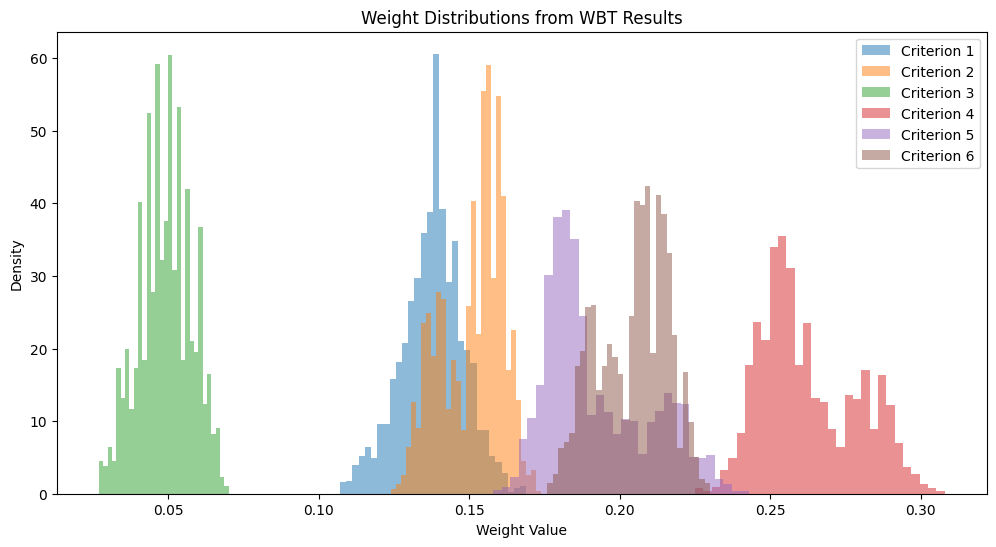

In [6]:
# read wbt_results_1_weights.csv and wbt_results_2_weights.csv and compare the weight distributions
file_paths = ["wbt_results_1_weights.csv", "wbt_results_2_weights.csv"]
weight_data = []
for file_path in file_paths:
    with open(file_path, 'r') as f:
        reader = csv.reader(f)
        headers = next(reader)
        for row in reader:
            weight_data.append([float(x) for x in row])
weight_data = np.array(weight_data)
num_criteria = weight_data.shape[1]
# Plot weight distributions
plt.figure(figsize=(12, 6))
for i in range(num_criteria):
    plt.hist(weight_data[:, i], label=f'Criterion {i+1}', alpha=0.5, bins=30, density=True)
plt.title('Weight Distributions from WBT Results')
plt.xlabel('Weight Value')
plt.ylabel('Density')
plt.legend()
plt.show()

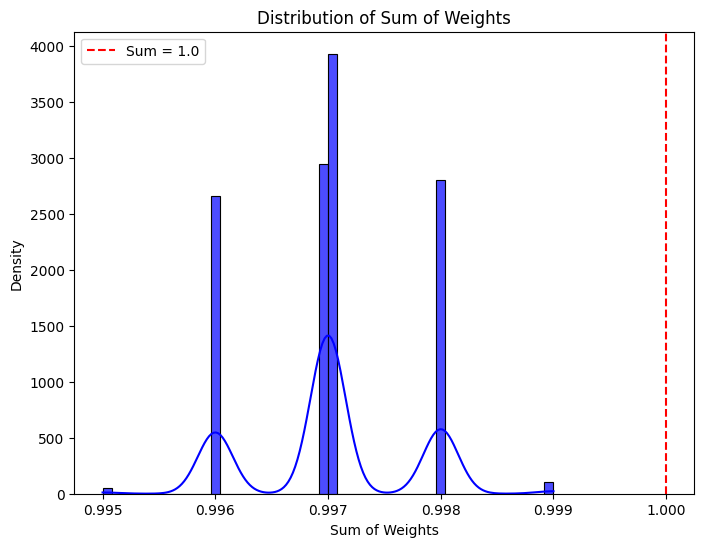

In [7]:
# Histogram of the distribution of the sums of weights
# Histogram of the distribution of the sums of weights
weight_sums = weight_data.sum(axis=1)  # sum across criteria for each sample
plt.figure(figsize=(8, 6))
sns.histplot(weight_sums, bins=50, stat='density', color='blue', alpha=0.7, kde=True)
plt.title('Distribution of Sum of Weights')
plt.xlabel('Sum of Weights')
plt.ylabel('Density')
plt.axvline(1.0, color='red', linestyle='--', label='Sum = 1.0')
plt.legend()
plt.show()

In [8]:
# print the maximum sum of weights
print(f"Maximum sum of weights: {np.max(weight_sums)}")
# print the culprit
max_sum_idx = np.argmax(weight_sums)
print(f"Culprit weights: {weight_data[max_sum_idx]} with sum {weight_sums[max_sum_idx]}")

Maximum sum of weights: 0.9990000000000001
Culprit weights: [0.132 0.141 0.049 0.278 0.202 0.197] with sum 0.9990000000000001
